<a href="https://colab.research.google.com/github/ftmrocca/CUBO-OLAP/blob/main/OLAP_Cubo_PySpark_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cubo OLAP con PySpark en Google Colab

Este notebook está preparado para ejecutarse en Colab y usa el modelo en estrella exportado desde SQL Server. Se clona el repositorio, se instala PySpark y se crean visualizaciones OLAP.

## 1. Preparación del entorno

Instala las dependencias necesarias y clona el repositorio para acceder a los CSV.

In [ ]:
!pip install --quiet pyspark pandas matplotlib seaborn
!git clone --depth 1 https://github.com/ftmrocca/CUBO-OLAP.git /content/CUBO-OLAP || true
import os
base_path = '/content/CUBO-OLAP'
assert os.path.exists(base_path), 'El repositorio no se clonó correctamente.'
print('base_path:', base_path)

Cloning into '/content/CUBO-OLAP'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 10 (delta 1), reused 5 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (10/10), 4.08 MiB | 4.35 MiB/s, done.
Resolving deltas: 100% (1/1), done.
base_path: /content/CUBO-OLAP


## 2. Crear sesión Spark y cargar datos

Creamos la sesión de Spark, cargamos cada dimensión y la tabla de hechos desde los CSV.

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, count, when, round, sum as spark_sum

spark = (SparkSession.builder
    .appName('CuboOLAPColab')
    .master('local[*]')
    .getOrCreate())

dim_candidate = (spark.read
    .option('header', 'true')
    .option('inferSchema', 'true')
    .csv(f'{base_path}/dim_candidate.csv'))

dim_education = (spark.read
    .option('header', 'true')
    .option('inferSchema', 'true')
    .csv(f'{base_path}/dim_education.csv'))

dim_skills = (spark.read
    .option('header', 'true')
    .option('inferSchema', 'true')
    .csv(f'{base_path}/dim_skills.csv'))

dim_time = (spark.read
    .option('header', 'true')
    .option('inferSchema', 'true')
    .csv(f'{base_path}/dim_time.csv'))

fact_employability = (spark.read
    .option('header', 'true')
    .option('inferSchema', 'true')
    .csv(f'{base_path}/fact_employability.csv'))

print('Datos cargados con éxito')
print('dim_candidate rows:', dim_candidate.count())
print('fact_employability rows:', fact_employability.count())

Datos cargados con éxito
dim_candidate rows: 432
fact_employability rows: 293445


## 3. Construcción del cubo OLAP

Unimos las dimensiones con la tabla de hechos para crear el cubo analítico.

In [ ]:
cube_df = (fact_employability
    .join(dim_candidate, 'candidate_id', 'left')
    .join(dim_education, 'education_id', 'left')
    .join(dim_skills, 'skills_id', 'left')
    .join(dim_time, 'time_id', 'left'))

cube_df.createOrReplaceTempView('cube')
cube_df.printSchema()

root
 |-- time_id: integer (nullable = true)
 |-- skills_id: integer (nullable = true)
 |-- education_id: integer (nullable = true)
 |-- candidate_id: integer (nullable = true)
 |-- fact_id: integer (nullable = true)
 |-- employment_status: string (nullable = true)
 |-- salary: integer (nullable = true)
 |-- job_sector: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- country_of_origin: string (nullable = true)
 |-- education_level: string (nullable = true)
 |-- field_of_study: string (nullable = true)
 |-- university_ranking: string (nullable = true)
 |-- region_of_study: string (nullable = true)
 |-- gpa: double (nullable = true)
 |-- language_proficiency: string (nullable = true)
 |-- internship_experience: string (nullable = true)
 |-- graduation_date: date (nullable = true)
 |-- years_since_graduation: integer (nullable = true)



## 4. Visualizaciones OLAP

Estas celdas generan gráficos que muestran distintos cortes y agregaciones del cubo.

### 4.1 Distribución de candidatos por género y país

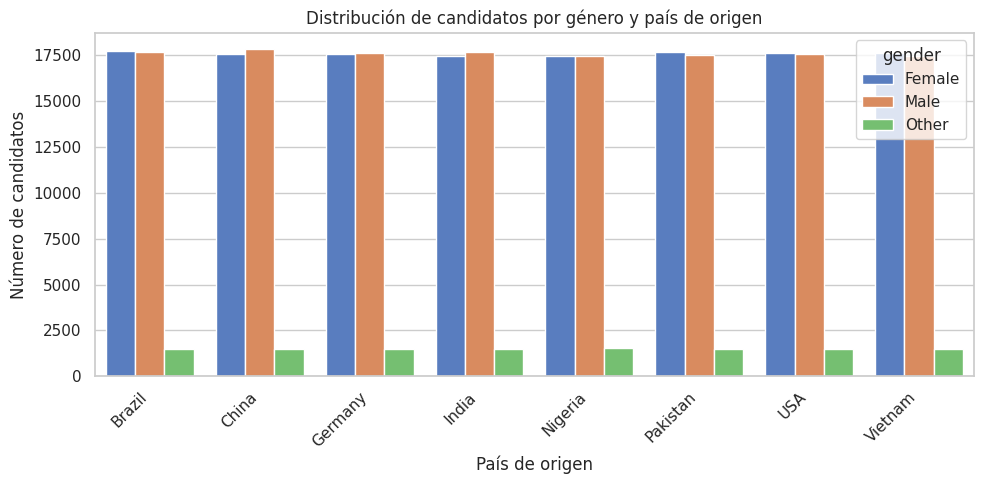

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', palette='muted')

gender_country = cube_df.groupBy('gender', 'country_of_origin').agg(count('*').alias('count')).orderBy('gender', 'country_of_origin')
pdf = gender_country.toPandas()
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=pdf, x='country_of_origin', y='count', hue='gender', ax=ax)
ax.set_title('Distribución de candidatos por género y país de origen')
ax.set_xlabel('País de origen')
ax.set_ylabel('Número de candidatos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.2 Tasa de empleo por nivel educativo

/tmp/ipykernel_12390/129913168.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdf, x='education_level', y='employment_rate', palette='Blues_d', ax=ax)


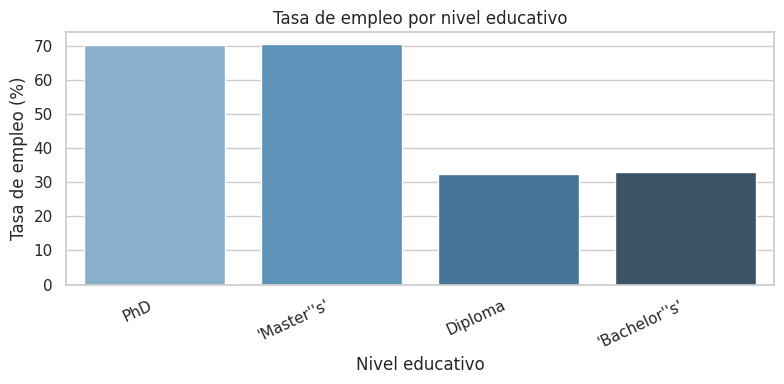

In [ ]:
education_employment = cube_df.groupBy('education_level').agg(
    count('*').alias('total'),
    spark_sum(when(col('employment_status') == 'Employed', 1).otherwise(0)).alias('employed')
)
education_employment = education_employment.withColumn('employment_rate', round(col('employed') / col('total') * 100, 2))
pdf = education_employment.toPandas()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=pdf, x='education_level', y='employment_rate', palette='Blues_d', ax=ax)
ax.set_title('Tasa de empleo por nivel educativo')
ax.set_xlabel('Nivel educativo')
ax.set_ylabel('Tasa de empleo (%)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

### 4.3 Salario promedio por sector y país

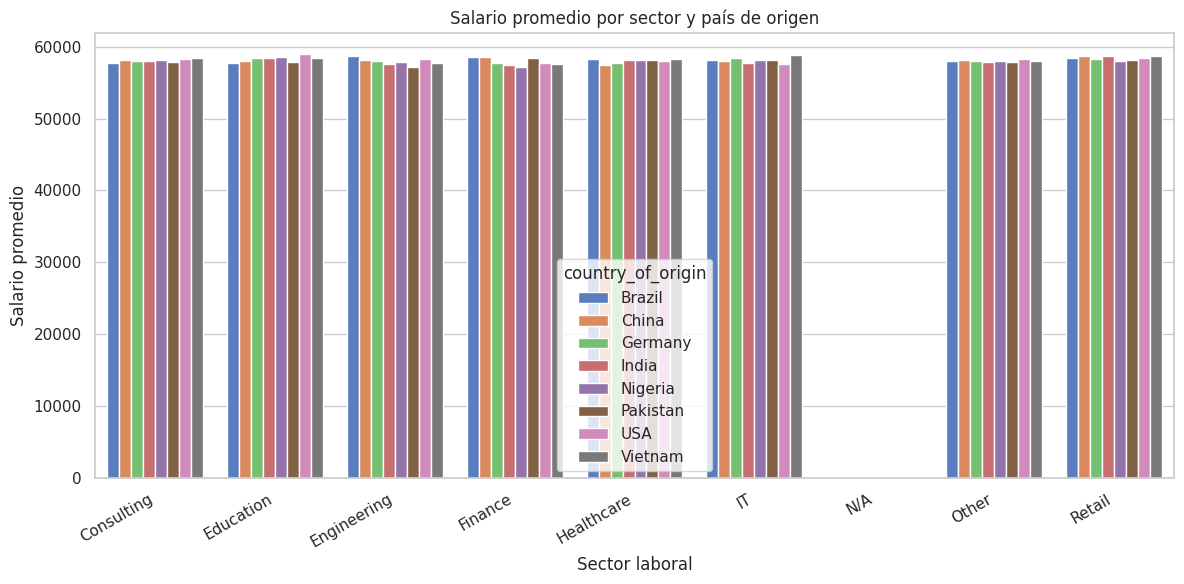

In [ ]:
salary_sector = cube_df.groupBy('job_sector', 'country_of_origin').agg(round(avg('salary'), 2).alias('avg_salary')).orderBy('job_sector', 'country_of_origin')
pdf = salary_sector.toPandas()
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=pdf, x='job_sector', y='avg_salary', hue='country_of_origin', ax=ax)
ax.set_title('Salario promedio por sector y país de origen')
ax.set_xlabel('Sector laboral')
ax.set_ylabel('Salario promedio')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 4.4 Experiencia de prácticas vs años desde graduación

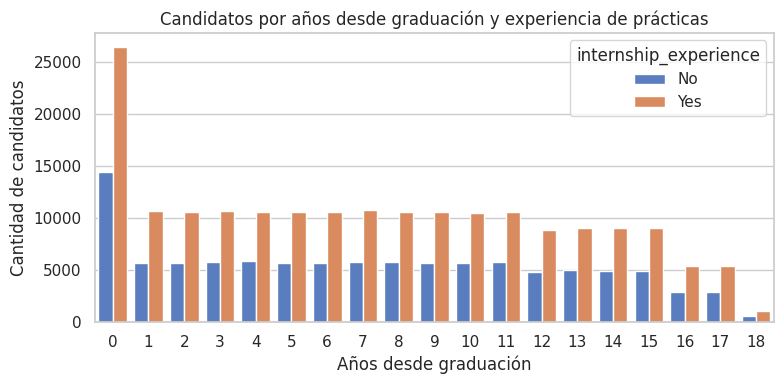

In [ ]:
experience_grad = cube_df.groupBy('years_since_graduation', 'internship_experience').agg(count('*').alias('count')).orderBy('years_since_graduation')
pdf = experience_grad.toPandas()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=pdf, x='years_since_graduation', y='count', hue='internship_experience', ax=ax)
ax.set_title('Candidatos por años desde graduación y experiencia de prácticas')
ax.set_xlabel('Años desde graduación')
ax.set_ylabel('Cantidad de candidatos')
plt.tight_layout()
plt.show()

### 4.5 Salario promedio por ranking universitario

/tmp/ipykernel_12390/1163330090.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdf, x='university_ranking', y='avg_salary', palette='viridis', ax=ax)


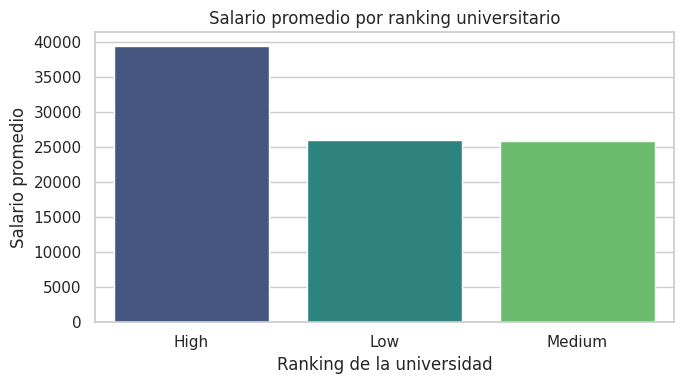

In [ ]:
salary_ranking = cube_df.groupBy('university_ranking').agg(round(avg('salary'), 2).alias('avg_salary')).orderBy('university_ranking')
pdf = salary_ranking.toPandas()
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=pdf, x='university_ranking', y='avg_salary', palette='viridis', ax=ax)
ax.set_title('Salario promedio por ranking universitario')
ax.set_xlabel('Ranking de la universidad')
ax.set_ylabel('Salario promedio')
plt.tight_layout()
plt.show()

## 6. Análisis Exploratorio Avanzado y Correlaciones
En esta sección profundizamos en la estructura del cubo mediante visualizaciones estadísticas avanzadas.

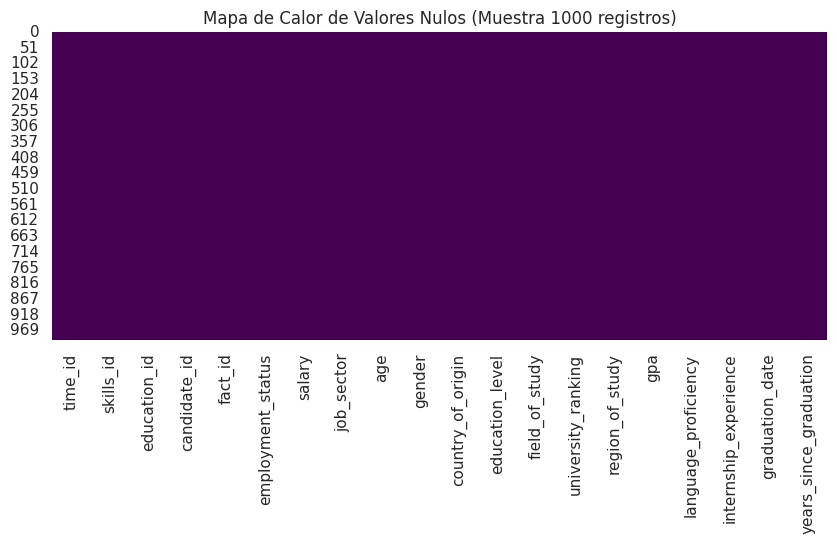

In [12]:
import numpy as np
# 6.1 Heatmap de Nulos
pdf_sample = cube_df.limit(1000).toPandas()
plt.figure(figsize=(10, 4))
sns.heatmap(pdf_sample.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Valores Nulos (Muestra 1000 registros)')
plt.show()

**Análisis de Nulos:** Esta visualización permite identificar rápidamente si existen patrones de pérdida de datos. Las líneas amarillas indicarían datos faltantes; en este caso, nos ayuda a validar la integridad del JOIN realizado en el cubo.

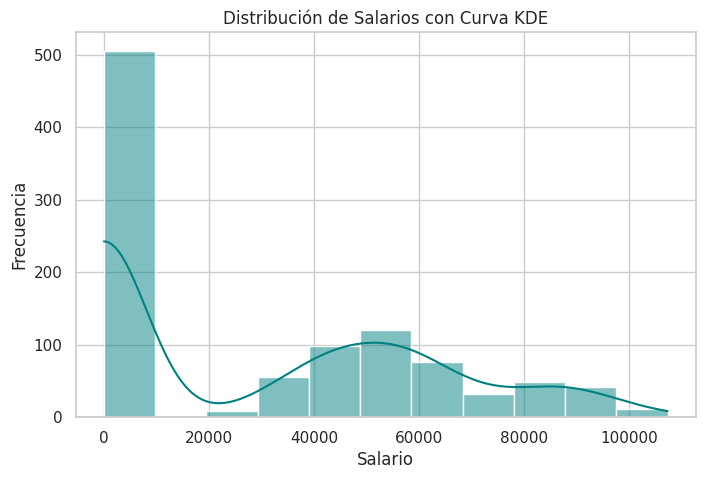

In [13]:
# 6.2 Histograma + Curva KDE del Salario
plt.figure(figsize=(8, 5))
sns.histplot(pdf_sample['salary'], kde=True, color='teal')
plt.title('Distribución de Salarios con Curva KDE')
plt.xlabel('Salario')
plt.ylabel('Frecuencia')
plt.show()

**Análisis de Distribución:** El histograma muestra la frecuencia de los salarios, mientras que la curva KDE (Kernel Density Estimate) suaviza la distribución para identificar modas o sesgos. Esto revela si la mayoría de los candidatos se concentran en rangos salariales bajos o altos.

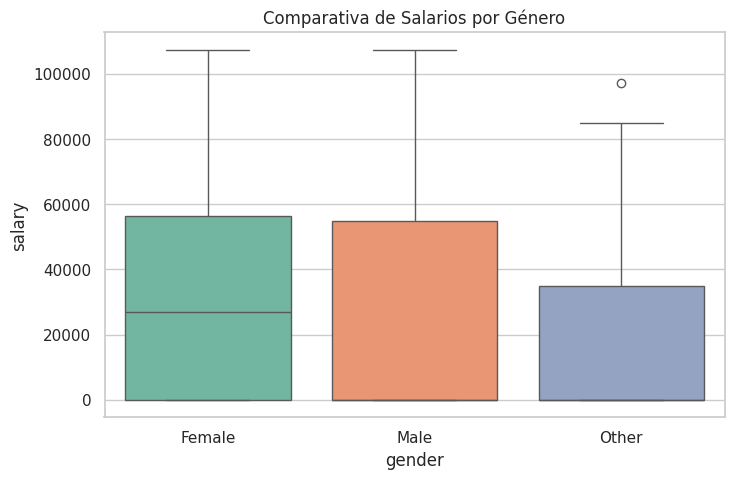

In [14]:
# 6.3 Boxplot Comparativo: Salario por Género
plt.figure(figsize=(8, 5))
sns.boxplot(data=pdf_sample, x='gender', y='salary', palette='Set2', hue='gender', legend=False)
plt.title('Comparativa de Salarios por Género')
plt.show()

**Análisis de Boxplot:** Representa la mediana, los cuartiles y los valores atípicos (outliers). Sirve para detectar disparidades salariales y variabilidad de ingresos entre diferentes grupos de género.

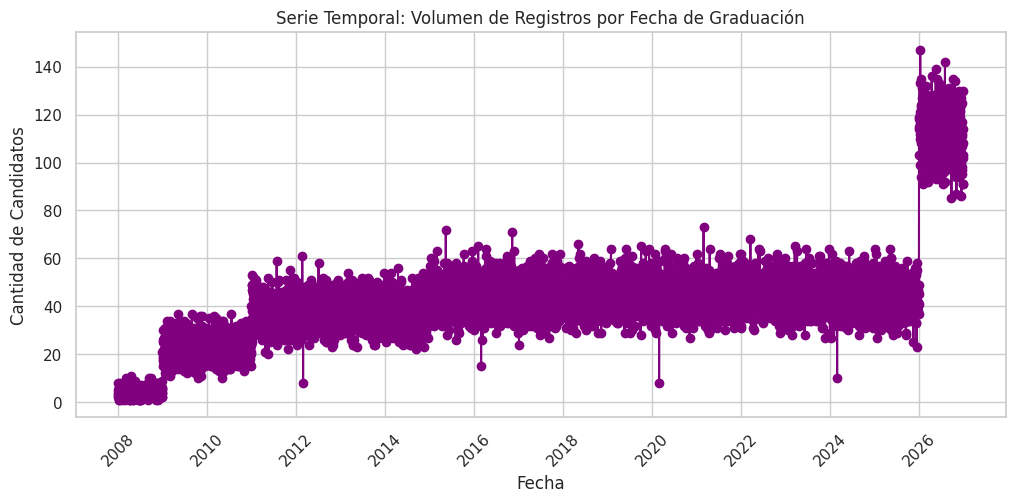

In [15]:
# 6.4 Serie Temporal: Volumen de graduaciones por fecha
time_series = cube_df.groupBy('graduation_date').agg(count('*').alias('volumen')).orderBy('graduation_date').toPandas()
plt.figure(figsize=(12, 5))
plt.plot(time_series['graduation_date'], time_series['volumen'], marker='o', linestyle='-', color='purple')
plt.title('Serie Temporal: Volumen de Registros por Fecha de Graduación')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Candidatos')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**Análisis Temporal:** Esta gráfica de líneas muestra cómo ha evolucionado el flujo de graduados en el tiempo. Permite detectar estacionalidad (picos en ciertos meses) o tendencias de crecimiento en la base de datos.

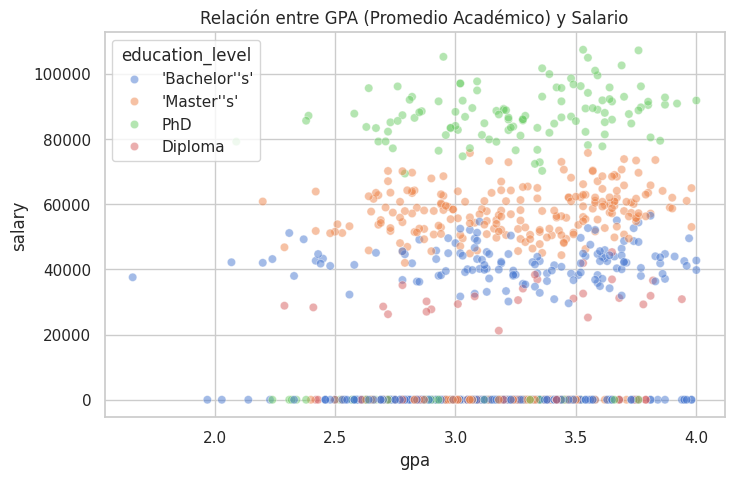

In [16]:
# 6.5 Scatter Plot: GPA vs Salario
plt.figure(figsize=(8, 5))
sns.scatterplot(data=pdf_sample, x='gpa', y='salary', alpha=0.5, hue='education_level')
plt.title('Relación entre GPA (Promedio Académico) y Salario')
plt.show()

**Análisis de Correlación (Scatter):** El gráfico de dispersión ayuda a visualizar si existe una relación directa entre el rendimiento académico (GPA) y el salario inicial. Si los puntos forman una línea ascendente, habría una correlación positiva.

## 5. Conclusión

Este notebook muestra cómo crear un cubo OLAP con PySpark a partir de un modelo en estrella y cómo visualizar los resultados en Colab.